## ML MODEL SUMMARIZER - CREDIT DATA EXPLORER WITH CLAUDE

### 03: XGB Model Tuning & Production

==================================================================
#### SECTION 1: IMPORT PACKAGES & DATA LOADING
==================================================================

In [54]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


In [55]:
df_model = pd.read_csv('../data/processed_loan_data.csv')

In [56]:
df_model = df_model.drop(['grade_encoded', 'sub_grade_encoded', 'last_pymnt_amnt_log_encoded'], axis=1) 

In [57]:
df_model['default_flag'].value_counts()

default_flag
0.0    1078712
1.0     269357
Name: count, dtype: int64

==================================================================
#### SECTION 2: FEATURE IMPORTANCE
==================================================================

In [58]:
#set the seed for reproducibility across all random operations
seed = 42
np.random.seed(seed)
random.seed(42)

In [59]:
X = df_model.drop('default_flag', axis=1)  
y = df_model['default_flag']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)

In [60]:
model = XGBClassifier(eval_metric='logloss', random_state=seed)

In [61]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [62]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

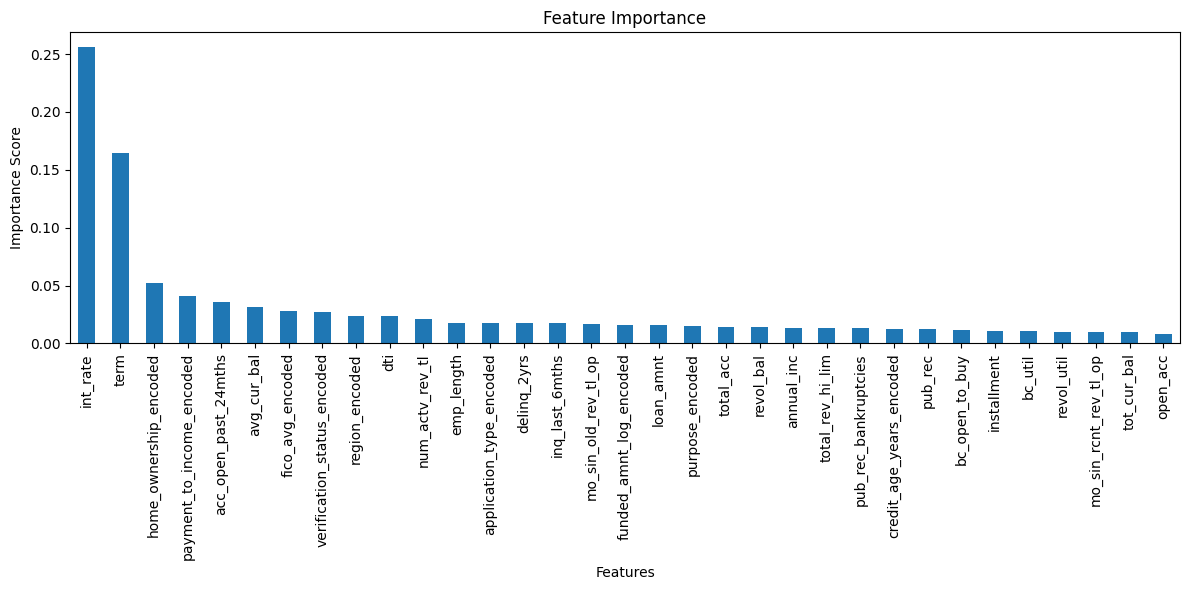

In [63]:
feat_imp.plot(kind='bar', figsize=(12, 6))
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

==================================================================
#### SECTION 3: MODEL BENCHMARK
==================================================================

In [64]:
y_pred = model.predict(X_test)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.8046818785374646
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    431485
         1.0       0.56      0.11      0.18    107743

    accuracy                           0.80    539228
   macro avg       0.69      0.54      0.54    539228
weighted avg       0.76      0.80      0.75    539228



In [90]:
y_proba = model.predict_proba(X_test)[:, 1]  # probability of default
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

ROC AUC Score: 0.722


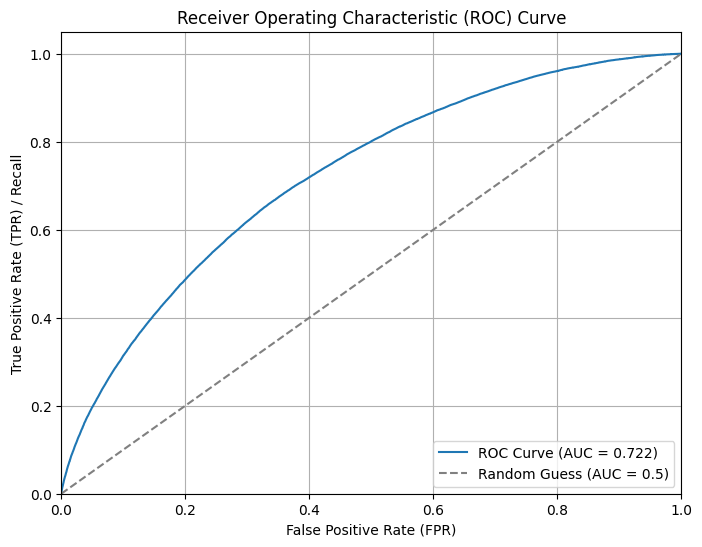

In [92]:
# 1. Calculate FPR and TPR for all thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 2. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
# Plot the random guess line (AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')

# 3. Add labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

==================================================================
#### SECTION 4: RECALL TESTING WITH SCALE_POS_WEIGHT
==================================================================

In [101]:
model = XGBClassifier(
    eval_metric='logloss', 
    random_state=seed,
    scale_pos_weight = 4.0)

In [102]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)  # X_test is still the real distribution

In [103]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.6593945418264631
              precision    recall  f1-score   support

         0.0       0.89      0.66      0.76    215743
         1.0       0.33      0.67      0.44     53871

    accuracy                           0.66    269614
   macro avg       0.61      0.66      0.60    269614
weighted avg       0.78      0.66      0.69    269614



In [104]:
y_proba = model.predict_proba(X_test)[:, 1]  # probability of default
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.3f}")

ROC AUC Score: 0.725


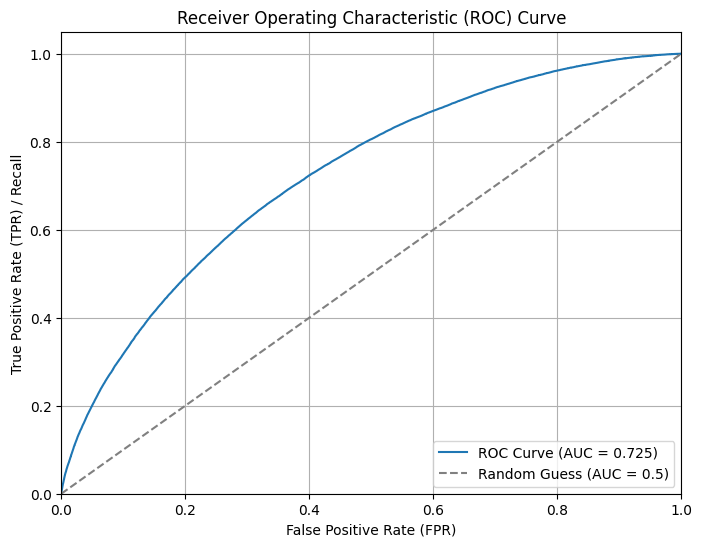

In [105]:
# 1. Calculate FPR and TPR for all thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# 2. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
# Plot the random guess line (AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')

# 3. Add labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

==================================================================
#### SECTION 4: RANDOMSEARCH CV FOR HYPERPARAMETER TUNING
==================================================================

In [106]:
param_dist = {
    # Tree structure
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    
    # Learning
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    
    # Sampling - prevents overfitting
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    
    # Regularization
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],      # L1
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],   # L2
    
    # Imbalance handling
    'scale_pos_weight': [1, 2, 4, 6, 8]
}

In [107]:
base_model = XGBClassifier(
    eval_metric='logloss',
    random_state=seed,
    n_jobs=-1
)

In [108]:
random_search = RandomizedSearchCV(
    estimator = base_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',  # or 'recall' or 'f1'
    random_state=seed,
    n_jobs=-1
)

In [109]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [110]:
print("Best Parameters:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 2, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.6}
Best CV AUC: 0.7286795052728806


In [113]:
param_dist = {
    # Tree structure
    'n_estimators': np.arange(150, 301, 50).tolist(),
    'max_depth': np.arange(6, 9).tolist(),
    
    # Learning
    'learning_rate': np.arange(0.08, 1.5, 0.05).tolist(),
    
    # Sampling - prevents overfitting
    'subsample': np.arange(0.9, 1.2, 0.1).tolist(),
    'colsample_bytree': np.arange(0.4, 0.5, 0.1).tolist(),

    # Imbalance handling
    'scale_pos_weight': np.arange(1, 2.6, 0.1).round(1).tolist(),
    
    # Regularization
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],      # L1
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]   # L2
}

In [114]:
random_search = RandomizedSearchCV(
    estimator = base_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',  # or 'recall' or 'f1'
    random_state=seed,
    n_jobs=-1
)

In [116]:
random_search.fit(X_train, y_train)

/opt/homebrew/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
40 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/lib/python3.14/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
  File "/opt/homebrew/lib/python3.14/site-packages/xgboost/sklearn.py", line 1806, in fit
    self._Booster = train(
                    ~~~~~^

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.4], 'gamma': [0, 0.1, ...], 'learning_rate': [0.08, 0.13, ...], 'max_depth': [6, 7, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionc

In [117]:
results_df = pd.DataFrame(random_search.cv_results_)
results_df.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_scale_pos_weight,param_reg_lambda,param_reg_alpha,param_n_estimators,param_min_child_weight,...,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
19,21.725637,2.059281,0.585359,0.100138,0.9,2.5,2.0,0.0,200,5,...,0.4,"{'subsample': 0.9, 'scale_pos_weight': 2.5, 'r...",0.727157,0.728209,0.728908,0.726507,0.726774,0.727511,0.000907,1
3,37.462709,1.266932,1.393256,0.330764,1.0,1.3,0.5,0.1,300,3,...,0.4,"{'subsample': 1.0, 'scale_pos_weight': 1.3, 'r...",0.726847,0.727922,0.728460,0.726047,0.726006,0.727056,0.000989,2
15,22.815794,0.354724,0.817881,0.079940,0.9,2.4,2.0,0.5,250,3,...,0.4,"{'subsample': 0.9, 'scale_pos_weight': 2.4, 'r...",0.726482,0.727839,0.728814,0.726227,0.725914,0.727055,0.001098,3
6,18.822477,0.983668,0.532792,0.054912,1.0,2.1,1.5,0.0,150,1,...,0.4,"{'subsample': 1.0, 'scale_pos_weight': 2.1, 'r...",0.726302,0.727105,0.728103,0.725476,0.725469,0.726491,0.001009,4
11,14.491878,0.135280,0.466214,0.040696,1.0,1.5,2.0,0.0,150,7,...,0.4,"{'subsample': 1.0, 'scale_pos_weight': 1.5, 'r...",0.725209,0.727085,0.727787,0.724951,0.724871,0.725980,0.001214,5
8,34.610690,0.407883,1.187813,0.036348,0.9,2.1,1.5,0.0,300,1,...,0.4,"{'subsample': 0.9, 'scale_pos_weight': 2.1, 'r...",0.718644,0.719217,0.720807,0.718142,0.718108,0.718983,0.000997,6
13,25.961812,0.181355,0.832308,0.031440,1.0,2.4,0.5,0.1,250,3,...,0.4,"{'subsample': 1.0, 'scale_pos_weight': 2.4, 'r...",0.715778,0.716680,0.718227,0.715931,0.714990,0.716321,0.001094,7
16,19.210962,0.495530,0.617823,0.026718,0.9,1.3,1.5,1.0,150,3,...,0.4,"{'subsample': 0.9, 'scale_pos_weight': 1.3, 'r...",0.708632,0.708768,0.710014,0.706515,0.708862,0.708558,0.001135,8
2,17.890731,0.136842,0.804472,0.036996,1.0,1.7,0.5,0.1,150,7,...,0.4,"{'subsample': 1.0, 'scale_pos_weight': 1.7, 'r...",0.702382,0.703709,0.705244,0.703383,0.702951,0.703534,0.000964,9
17,28.041720,0.911578,0.997899,0.050464,0.9,2.0,1.0,0.1,250,1,...,0.4,"{'subsample': 0.9, 'scale_pos_weight': 2.0, 'r...",0.683565,0.683268,0.685681,0.685322,0.684761,0.684519,0.000952,10
